# Sultanov Kanan 606.23E – Artificial Intelligence Lab 3
# Handwritten Digit Classification on MNIST Using Convolutional Neural Networks

In [20]:
import torch
import numpy as np
import torchvision
import torch.nn.functional as F
import matplotlib.pyplot as plt
import torch.optim as optim
from torch import nn
from tqdm.notebook import tqdm
from torchvision.datasets import MNIST
from torch.utils.data import random_split, DataLoader, TensorDataset
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
%config InlineBackend.figure_format = 'retina'
import torch.nn as nn

In [6]:
transform = torchvision.transforms.Compose([
        torchvision.transforms.ToTensor(),
        torchvision.transforms.Normalize((0.1307, ), (0.3081, )),
])

For the first task regarding data preparation, I begin by importing the MNIST dataset and dividing it into three parts: training, validation, and testing. The training set is primarily used to teach our neural network how to recognize the underlying patterns within the images. Meanwhile, the validation set allows us to monitor the model's performance during the actual training process, which is crucial for tuning hyperparameters and preventing the model from overfitting. We keep the test set completely isolated until the very end
to provide a fair and unbiased evaluation of our final model's accuracy.

In [7]:
full_train_dataset = torchvision.datasets.MNIST('./mnist/', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.MNIST('./mnist/', train=False, download=True, transform=transform)

generator = torch.Generator().manual_seed(42)
train_dataset, val_dataset = random_split(full_train_dataset, [50000, 10000], generator=generator)

batch_size = 40

train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=1)
val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=1)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=1)

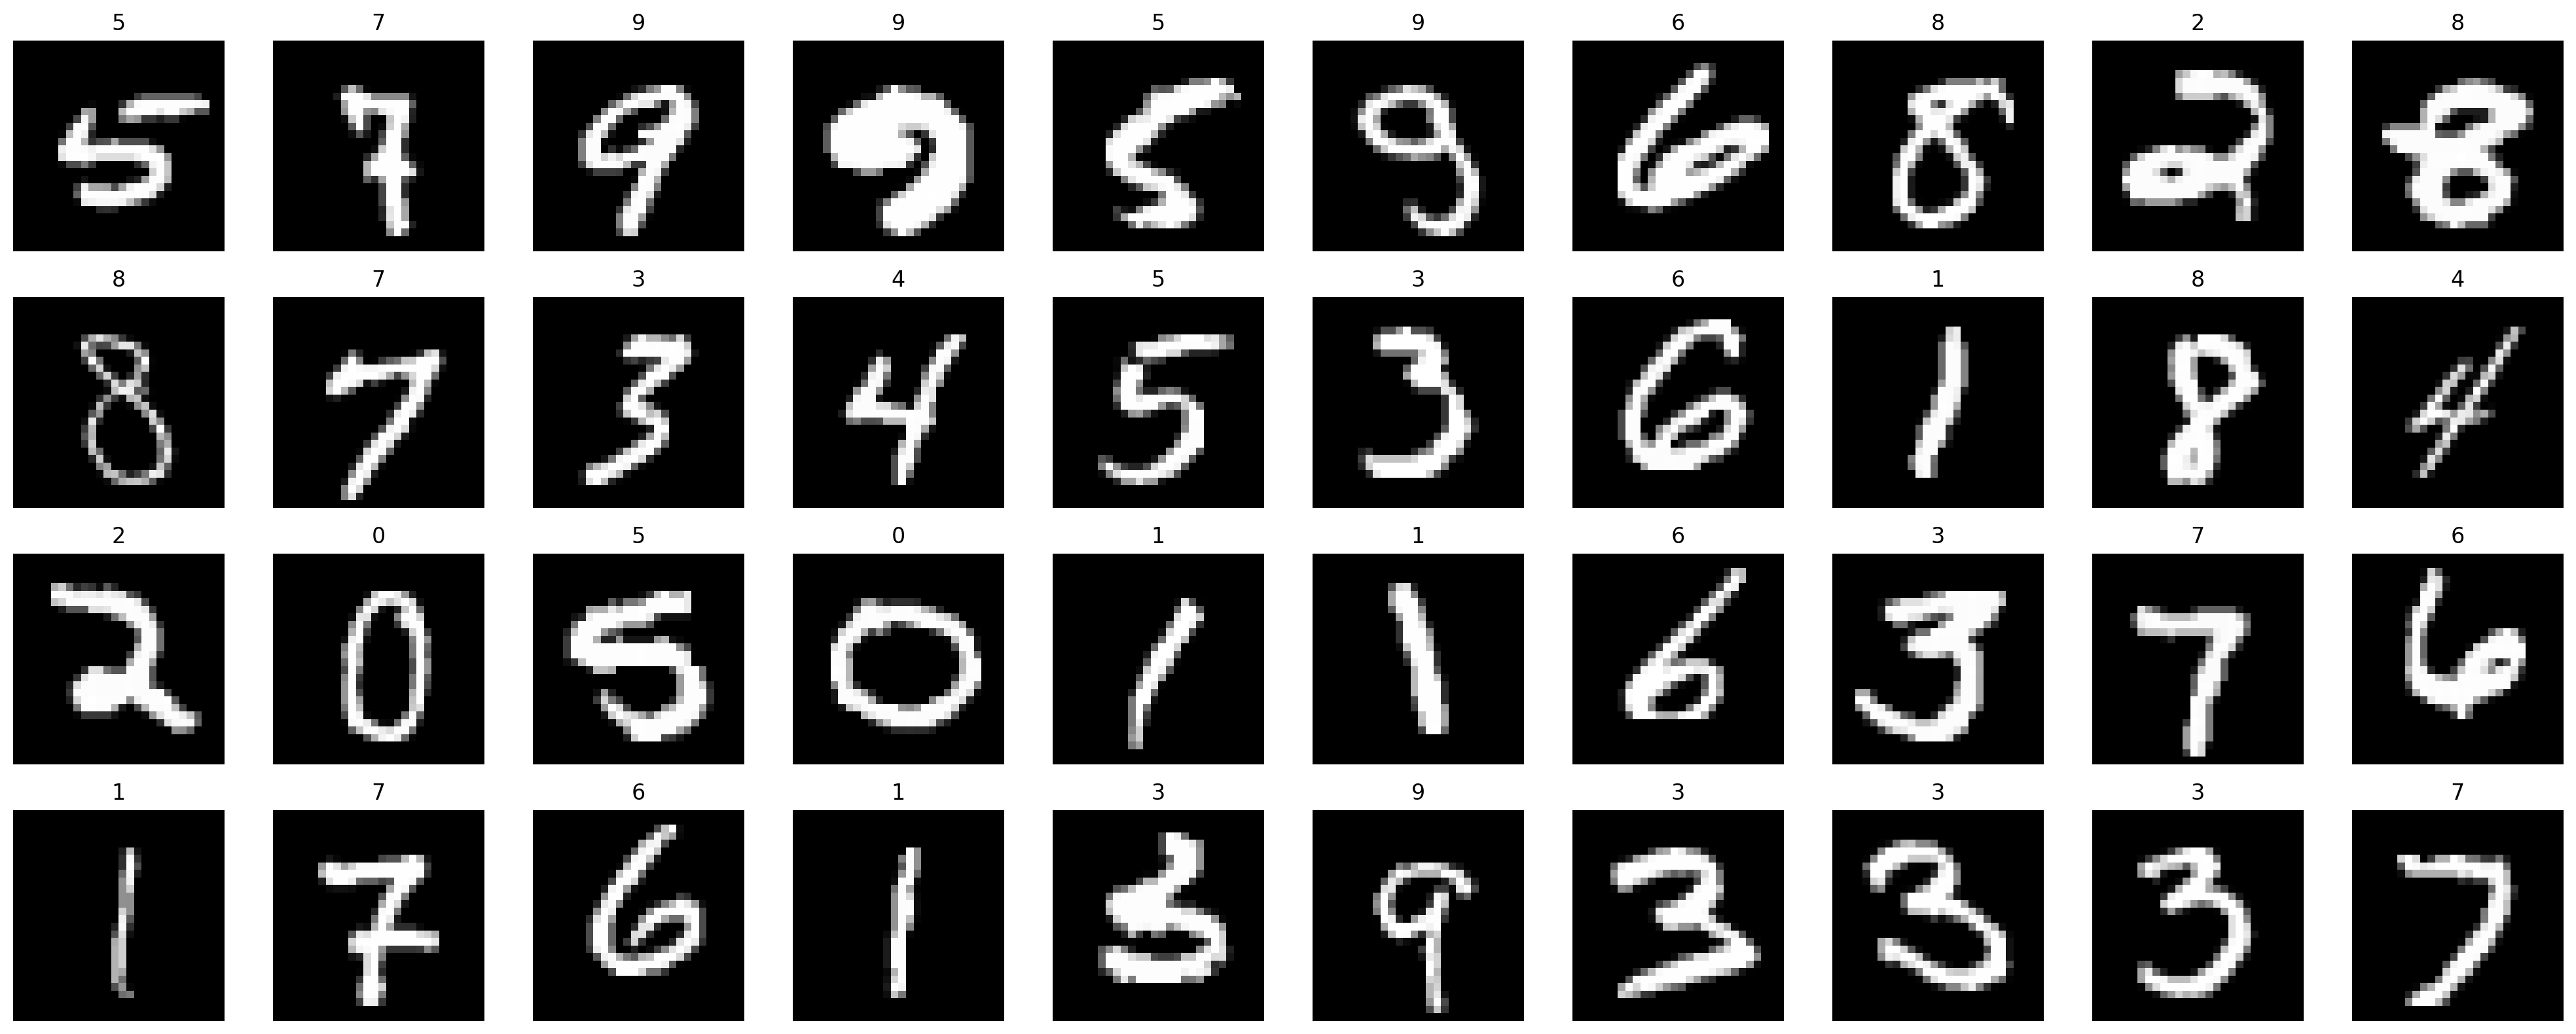

In [8]:
images, labels = next(iter(train_dataloader))
fig, axes = plt.subplots(4, 10, figsize = (20, 8))

for i, ax in enumerate(axes.flat):
    ax.imshow(images[i][0], cmap = 'gray')
    ax.set_title(labels[i].item())
    ax.axis('off')

plt.tight_layout()
plt.show()

To establish a benchmark for our classification task, I built a simple Convolutional Neural Network consisting of two primary stages of feature extraction and a final classification head. Each stage utilizes a convolutional layer to detect spatial patterns followed by a ReLU activation to introduce non-linearity and a max-pooling layer to reduce dimensionality while preserving essential information. After the data passes through these layers, it is flattened into a one-dimensional vector so that it can be processed by the dense linear layers. The first linear layer analyzes the combined features to understand the image content, and the final output layer maps these signals to ten neurons representing the digits zero through nine. This architecture provides a robust yet straightforward starting point that effectively captures the structural hierarchy of the MNIST digits

In [9]:
model = nn.Sequential(
    nn.Conv2d(in_channels = 1, out_channels = 10, kernel_size = 5),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2),
    nn.Conv2d(in_channels = 10, out_channels = 20, kernel_size = 5),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size = 2),
    nn.Flatten(),
    nn.Linear(320, 128),
    nn.ReLU(),
    nn.Linear(128, 10)
)

In [10]:
optimizer = torch.optim.SGD(model.parameters(), lr = 0.05)

In [11]:
device = torch.device('cuda')

In [12]:
device

device(type='cuda')

In [13]:
model.to(device)

Sequential(
  (0): Conv2d(1, 10, kernel_size=(5, 5), stride=(1, 1))
  (1): ReLU()
  (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (3): Conv2d(10, 20, kernel_size=(5, 5), stride=(1, 1))
  (4): ReLU()
  (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (6): Flatten(start_dim=1, end_dim=-1)
  (7): Linear(in_features=320, out_features=128, bias=True)
  (8): ReLU()
  (9): Linear(in_features=128, out_features=10, bias=True)
)

In [14]:
def train(model, train_dataloader, val_dataloader, optimizer, device, epochs = 5):

    model.to(device)

    for epoch in range(epochs):
        model.train()
        for x_train, y_train in tqdm(train_dataloader, desc = f"Epoch {epoch+1}/{epochs}"):
            y_pred = model(x_train.to(device))
            loss = F.cross_entropy(y_pred, y_train.to(device))

            loss.backward()
            optimizer.step()
            optimizer.zero_grad()

        if epoch % 2 == 0:
            model.eval()
            val_loss = [ ]
            val_accuracy = [ ]

            with torch.no_grad():
                for x_val, y_val in tqdm(val_dataloader, desc = 'Validation'):
                    y_pred = model(x_val.to(device))
                    loss = F.cross_entropy(y_pred, y_val.to(device))
                    val_loss.append(loss.cpu().numpy())

                    preds = torch.argmax(y_pred, dim = -1)
                    acc = (preds == y_val.to(device)).cpu().numpy()
                    val_accuracy.extend(acc.tolist())

            mean_loss = np.mean(val_loss)
            mean_acc = np.mean(val_accuracy)

            print(f"Epoch {epoch+1}: val_loss={mean_loss:.4f}, val_acc={mean_acc:.4f}")

In [15]:
print(f"Training model with {sum([x[1].numel() for x in model.named_parameters()])} parameters")
train(model, train_dataloader, val_dataloader, optimizer, device, epochs = 10)

Training model with 47658 parameters


Epoch 1/10:   0%|          | 0/1250 [00:00<?, ?it/s]

Validation:   0%|          | 0/250 [00:00<?, ?it/s]

Epoch 1: val_loss=0.0838, val_acc=0.9751


Epoch 2/10:   0%|          | 0/1250 [00:00<?, ?it/s]

...

Epoch 8/10:   0%|          | 0/1250 [00:00<?, ?it/s]

Epoch 9/10:   0%|          | 0/1250 [00:00<?, ?it/s]

Validation:   0%|          | 0/250 [00:00<?, ?it/s]

Epoch 9: val_loss=0.0424, val_acc=0.9886


Epoch 10/10:   0%|          | 0/1250 [00:00<?, ?it/s]

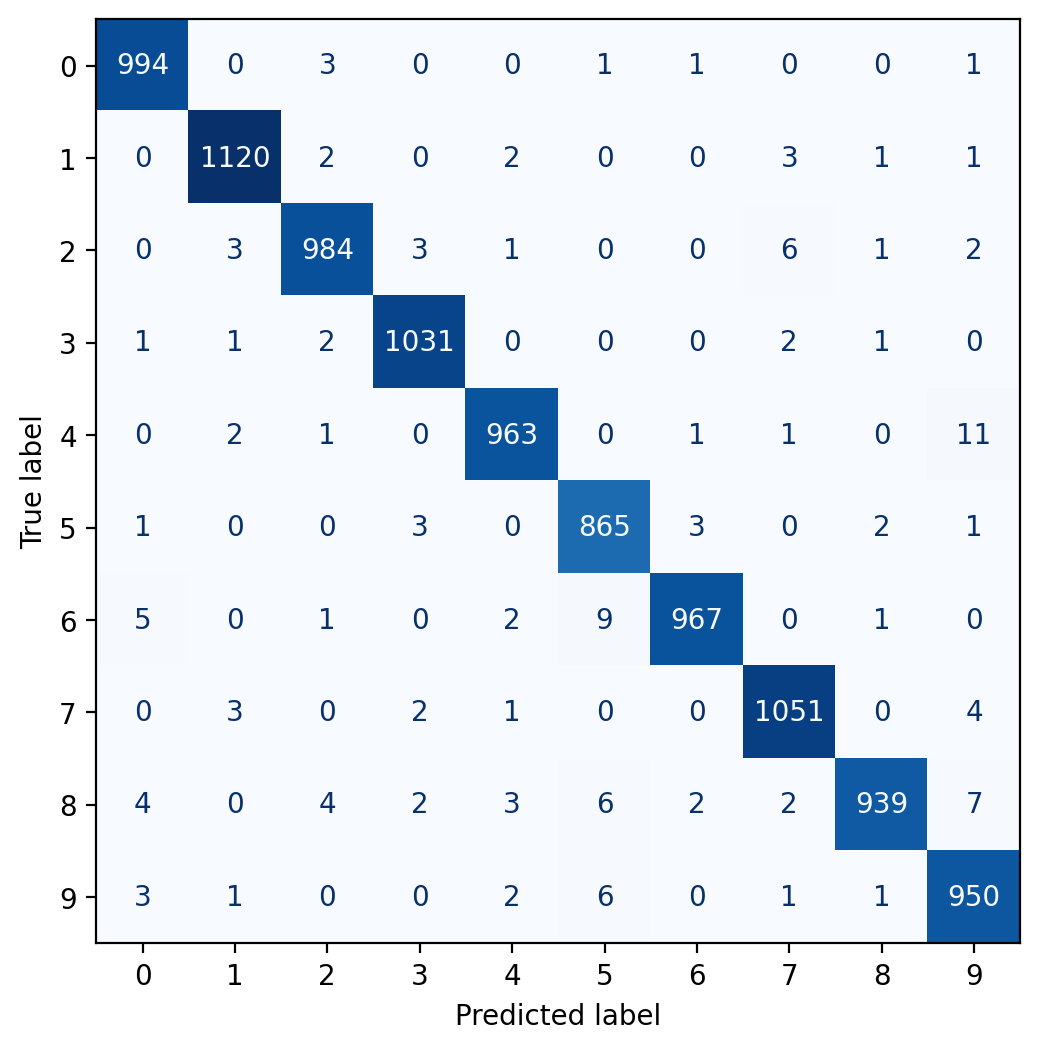

In [19]:
all_preds = [ ]
all_labels = [ ]

model.eval()
with torch.no_grad():
    for x_val, y_val in val_dataloader:
        x_val, y_val = x_val.to(device), y_val.to(device)
        y_pred = model(x_val)
        preds = torch.argmax(y_pred, dim = -1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y_val.cpu().numpy())

fig, ax = plt.subplots(figsize = (6, 6))
ConfusionMatrixDisplay.from_predictions(all_labels, all_preds, cmap = plt.cm.Blues, ax = ax, colorbar = False)
plt.show()

In [23]:
print(classification_report(all_labels, all_preds, digits=4))

              precision    recall  f1-score   support

           0     0.9861    0.9940    0.9900      1000
           1     0.9912    0.9920    0.9916      1129
           2     0.9870    0.9840    0.9855      1000
           3     0.9904    0.9933    0.9918      1038
           4     0.9887    0.9837    0.9862       979
           5     0.9752    0.9886    0.9818       875
           6     0.9928    0.9817    0.9872       985
           7     0.9859    0.9906    0.9882      1061
           8     0.9926    0.9690    0.9807       969
           9     0.9724    0.9855    0.9789       964

    accuracy                         0.9864     10000
   macro avg     0.9862    0.9862    0.9862     10000
weighted avg     0.9865    0.9864    0.9864     10000



In [24]:
def show_errors(model, dataloader, device, n_images=24, cols=6):
    model.eval()
    images_shown = 0
    rows = int(np.ceil(n_images / cols))

    fig, axes = plt.subplots(rows, cols, figsize=(16, 8))

    with torch.no_grad():
        for x_batch, y_batch in dataloader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            y_pred = model(x_batch)
            preds = torch.argmax(y_pred, dim=1)

            for i in range(x_batch.size(0)):
                if images_shown >= n_images:
                    break
                if preds[i] != y_batch[i]:
                    ax = axes.flat[images_shown]
                    ax.imshow(x_batch[i][0].cpu(), cmap='gray')
                    ax.set_title(f"Pred: {preds[i].item()}\nTrue: {y_batch[i].item()}", color='red')
                    ax.axis('off')
                    images_shown += 1
            if images_shown >= n_images:
                break

    plt.tight_layout()
    plt.show()

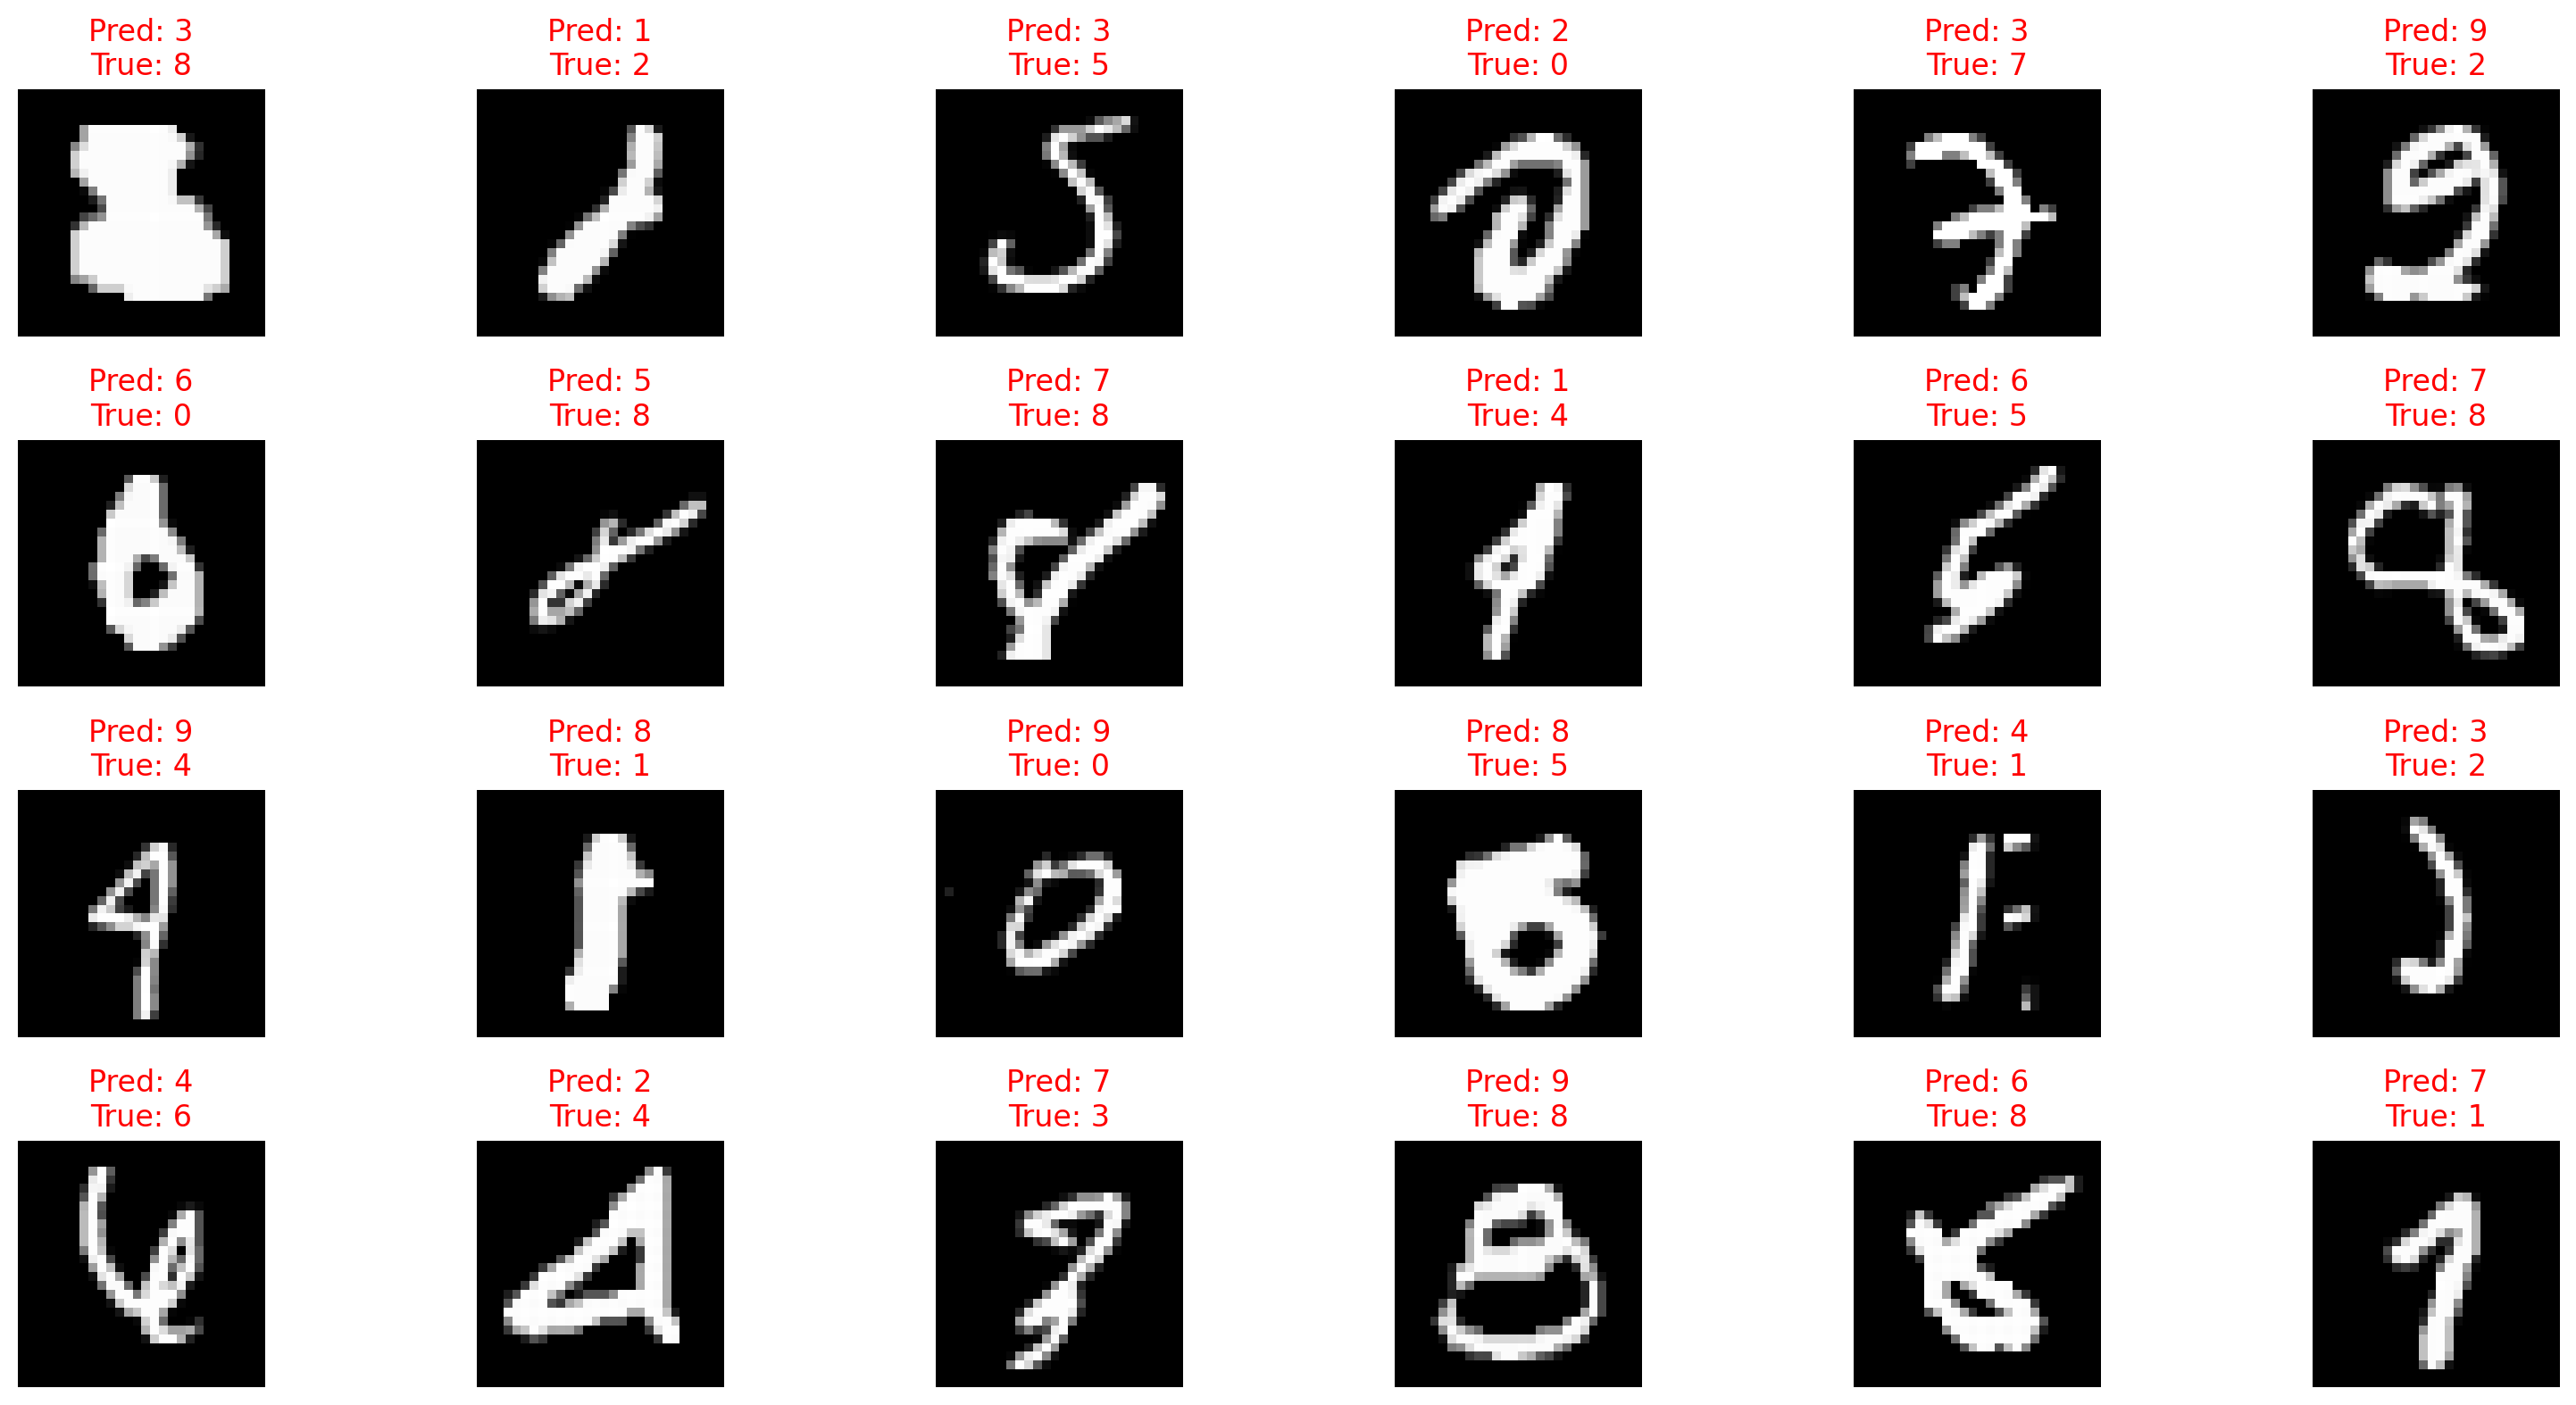

In [25]:
show_errors(model, val_dataloader, device, n_images = 24, cols = 6)

In [26]:
def create_model(conv2_filters=20, dropout_rate=0.5):
    model = nn.Sequential(
        nn.Conv2d(in_channels=1, out_channels=10, kernel_size=5),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2),
        nn.Conv2d(in_channels=10, out_channels=conv2_filters, kernel_size=5),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2),
        nn.Flatten(),
        nn.Linear(conv2_filters * 4 * 4, 128),
        nn.ReLU(),
        nn.Dropout(p=dropout_rate),
        nn.Linear(128, 10)
    )
    return model

In [28]:
def train_and_evaluate(model, train_dataloader, val_dataloader, optimizer, device, epochs=5):
    model.to(device)
    history = {'train_loss': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(epochs):
        model.train()
        train_loss_epoch = []
        for x_train, y_train in tqdm(train_dataloader, desc=f"Epoch {epoch+1}/{epochs}"):
            x_train, y_train = x_train.to(device), y_train.to(device)
            optimizer.zero_grad()
            y_pred = model(x_train)
            loss = F.cross_entropy(y_pred, y_train)
            loss.backward()
            optimizer.step()
            train_loss_epoch.append(loss.item())

        history['train_loss'].append(np.mean(train_loss_epoch))

        model.eval()
        val_loss_epoch = []
        val_acc_epoch = []
        with torch.no_grad():
            for x_val, y_val in val_dataloader:
                x_val, y_val = x_val.to(device), y_val.to(device)
                y_pred = model(x_val)
                loss = F.cross_entropy(y_pred, y_val)
                val_loss_epoch.append(loss.item())
                preds = torch.argmax(y_pred, dim=-1)
                acc = (preds == y_val).float().mean().item()
                val_acc_epoch.append(acc)

        mean_val_loss = np.mean(val_loss_epoch)
        mean_val_acc = np.mean(val_acc_epoch)
        history['val_loss'].append(mean_val_loss)
        history['val_acc'].append(mean_val_acc)

        print(f"Epoch {epoch+1}: val_loss={mean_val_loss:.4f}, val_acc={mean_val_acc:.4f}")

    return history

In [29]:
configs = [
    {"lr": 0.001, "optimizer": "Adam", "batch_size": 32, "dropout": 0.0, "filters": 20},
    {"lr": 0.01,  "optimizer": "SGD",  "batch_size": 64, "dropout": 0.2, "filters": 20},
    {"lr": 0.001, "optimizer": "Adam", "batch_size": 128, "dropout": 0.5, "filters": 32},
    {"lr": 0.05,  "optimizer": "SGD",  "batch_size": 32, "dropout": 0.5, "filters": 10},
]

In [31]:
all_histories = []

for i, config in enumerate(configs):
    print(f"Configuration: {config}")

    train_loader = DataLoader(train_dataset, batch_size=config["batch_size"], shuffle=True, num_workers=1)
    val_loader = DataLoader(val_dataset, batch_size=config["batch_size"], shuffle=False, num_workers=1)

    model_cv = create_model(conv2_filters=config["filters"], dropout_rate=config["dropout"])
    model_cv.to(device)

    if config["optimizer"] == "Adam":
        optimizer = optim.Adam(model_cv.parameters(), lr=config["lr"])
    else:
        optimizer = optim.SGD(model_cv.parameters(), lr=config["lr"], momentum=0.9)

    history = train_and_evaluate(model_cv, train_loader, val_loader, optimizer, device, epochs=5)
    all_histories.append((config, history))

Configuration: {'lr': 0.001, 'optimizer': 'Adam', 'batch_size': 32, 'dropout': 0.0, 'filters': 20}


Epoch 1/5:   0%|          | 0/1563 [00:00<?, ?it/s]

Epoch 1: val_loss=0.0628, val_acc=0.9814


Epoch 2/5:   0%|          | 0/1563 [00:00<?, ?it/s]

Epoch 2: val_loss=0.0573, val_acc=0.9823


...

Epoch 3: val_loss=2.3022, val_acc=0.1128


Epoch 4/5:   0%|          | 0/1563 [00:00<?, ?it/s]

Epoch 4: val_loss=2.3062, val_acc=0.0970


Epoch 5/5:   0%|          | 0/1563 [00:00<?, ?it/s]

Epoch 5: val_loss=2.3022, val_acc=0.1060


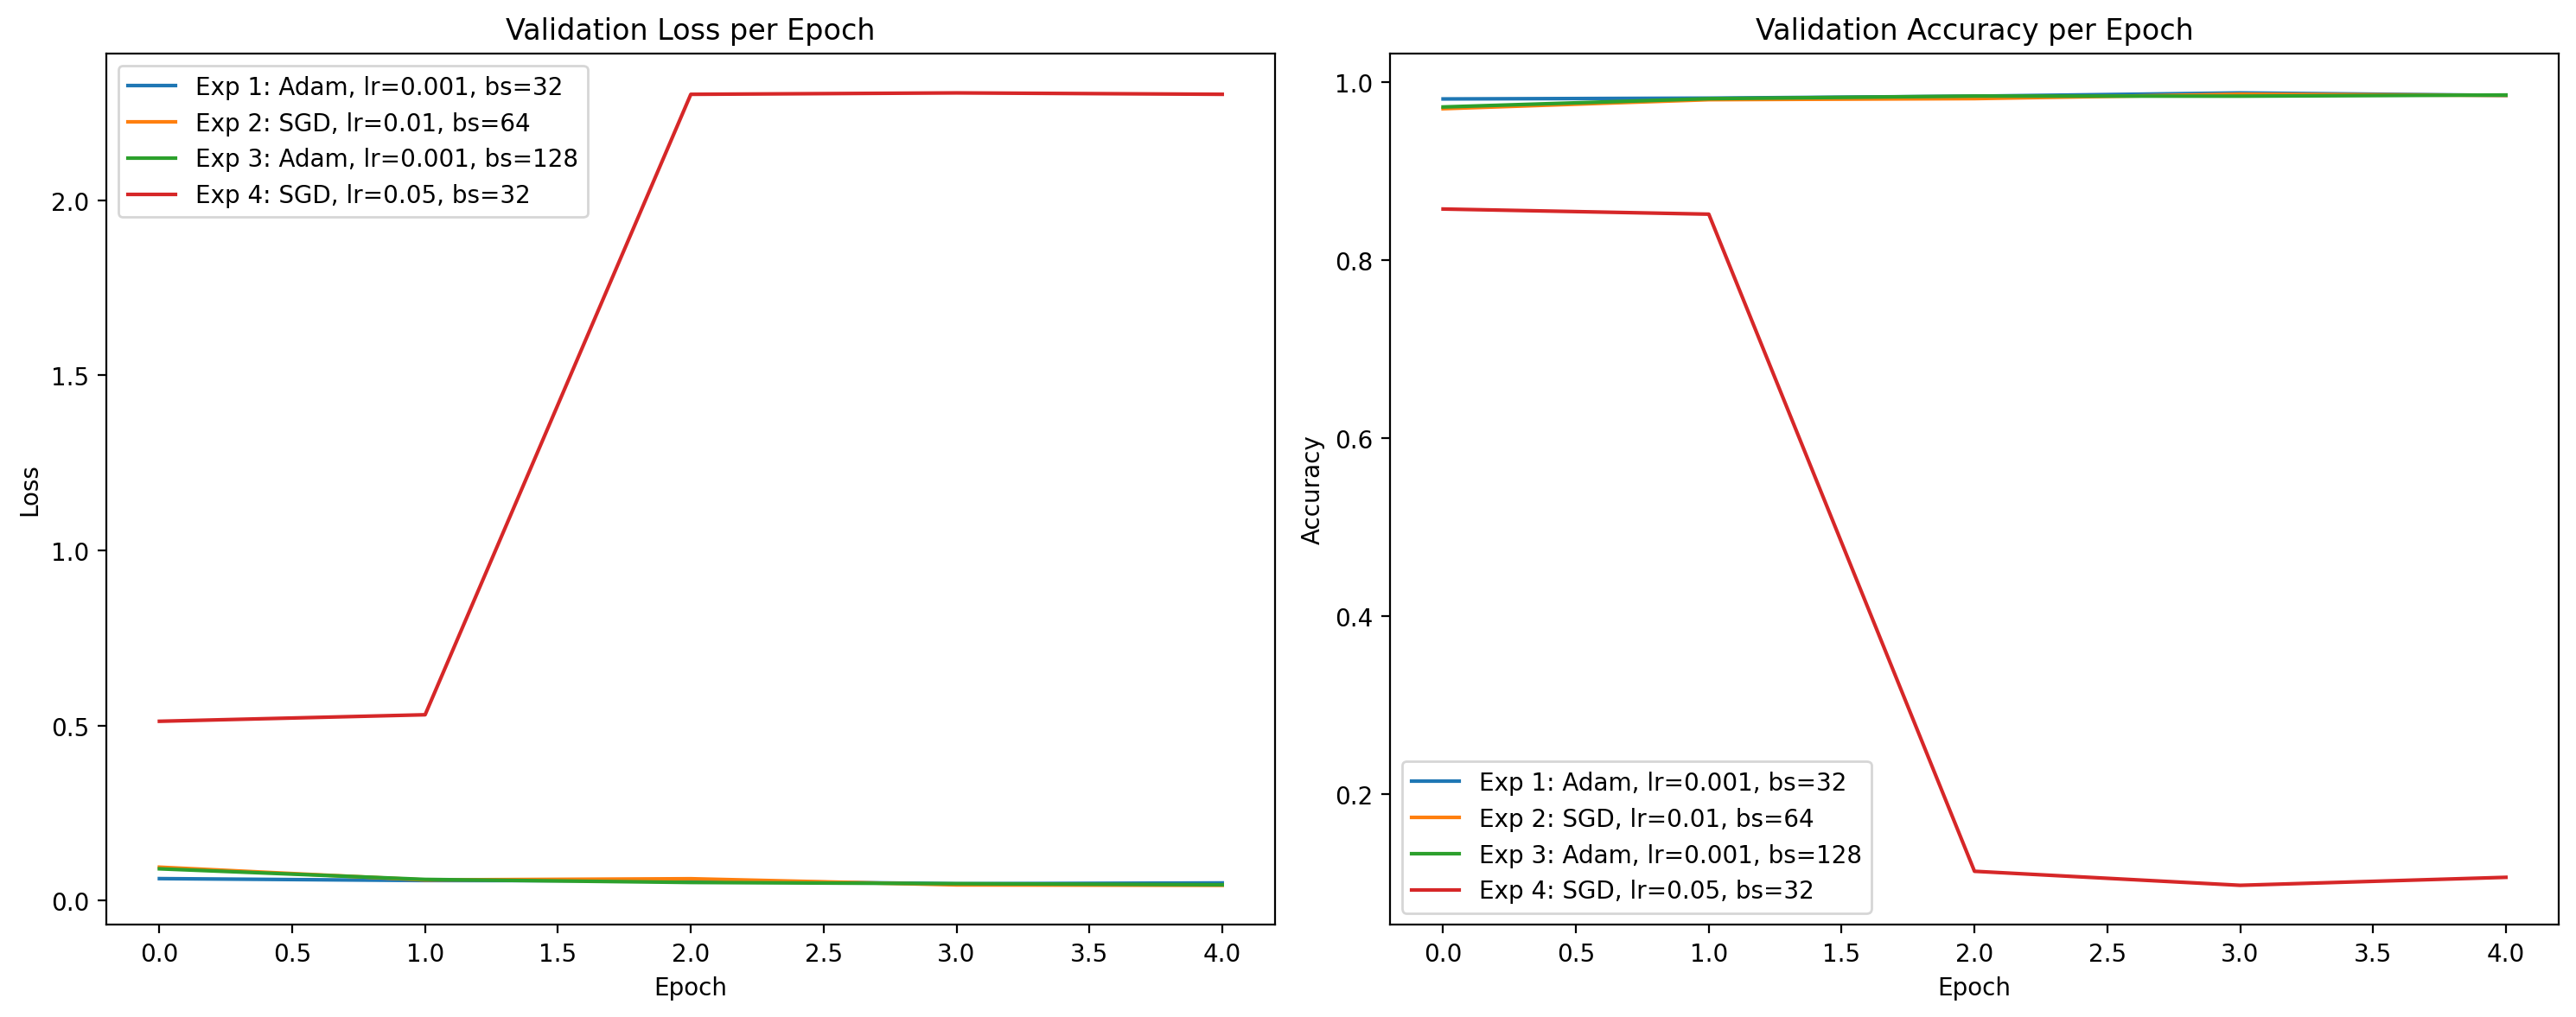

In [35]:
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
for i, (config, history) in enumerate(all_histories):
    label = f"Exp {i+1}: {config['optimizer']}, lr={config['lr']}, bs={config['batch_size']}"
    plt.plot(history['val_loss'], label=label)
plt.title("Validation Loss per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
for i, (config, history) in enumerate(all_histories):
    label = f"Exp {i+1}: {config['optimizer']}, lr={config['lr']}, bs={config['batch_size']}"
    plt.plot(history['val_acc'], label=label)
plt.title("Validation Accuracy per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

              precision    recall  f1-score   support

           0     0.9819    0.9980    0.9899       980
           1     0.9886    0.9974    0.9930      1135
           2     0.9951    0.9855    0.9903      1032
           3     0.9892    0.9970    0.9931      1010
           4     0.9898    0.9847    0.9872       982
           5     0.9932    0.9843    0.9887       892
           6     0.9926    0.9823    0.9874       958
           7     0.9798    0.9903    0.9850      1028
           8     0.9856    0.9867    0.9861       974
           9     0.9849    0.9722    0.9786      1009

    accuracy                         0.9880     10000
   macro avg     0.9881    0.9878    0.9879     10000
weighted avg     0.9880    0.9880    0.9880     10000



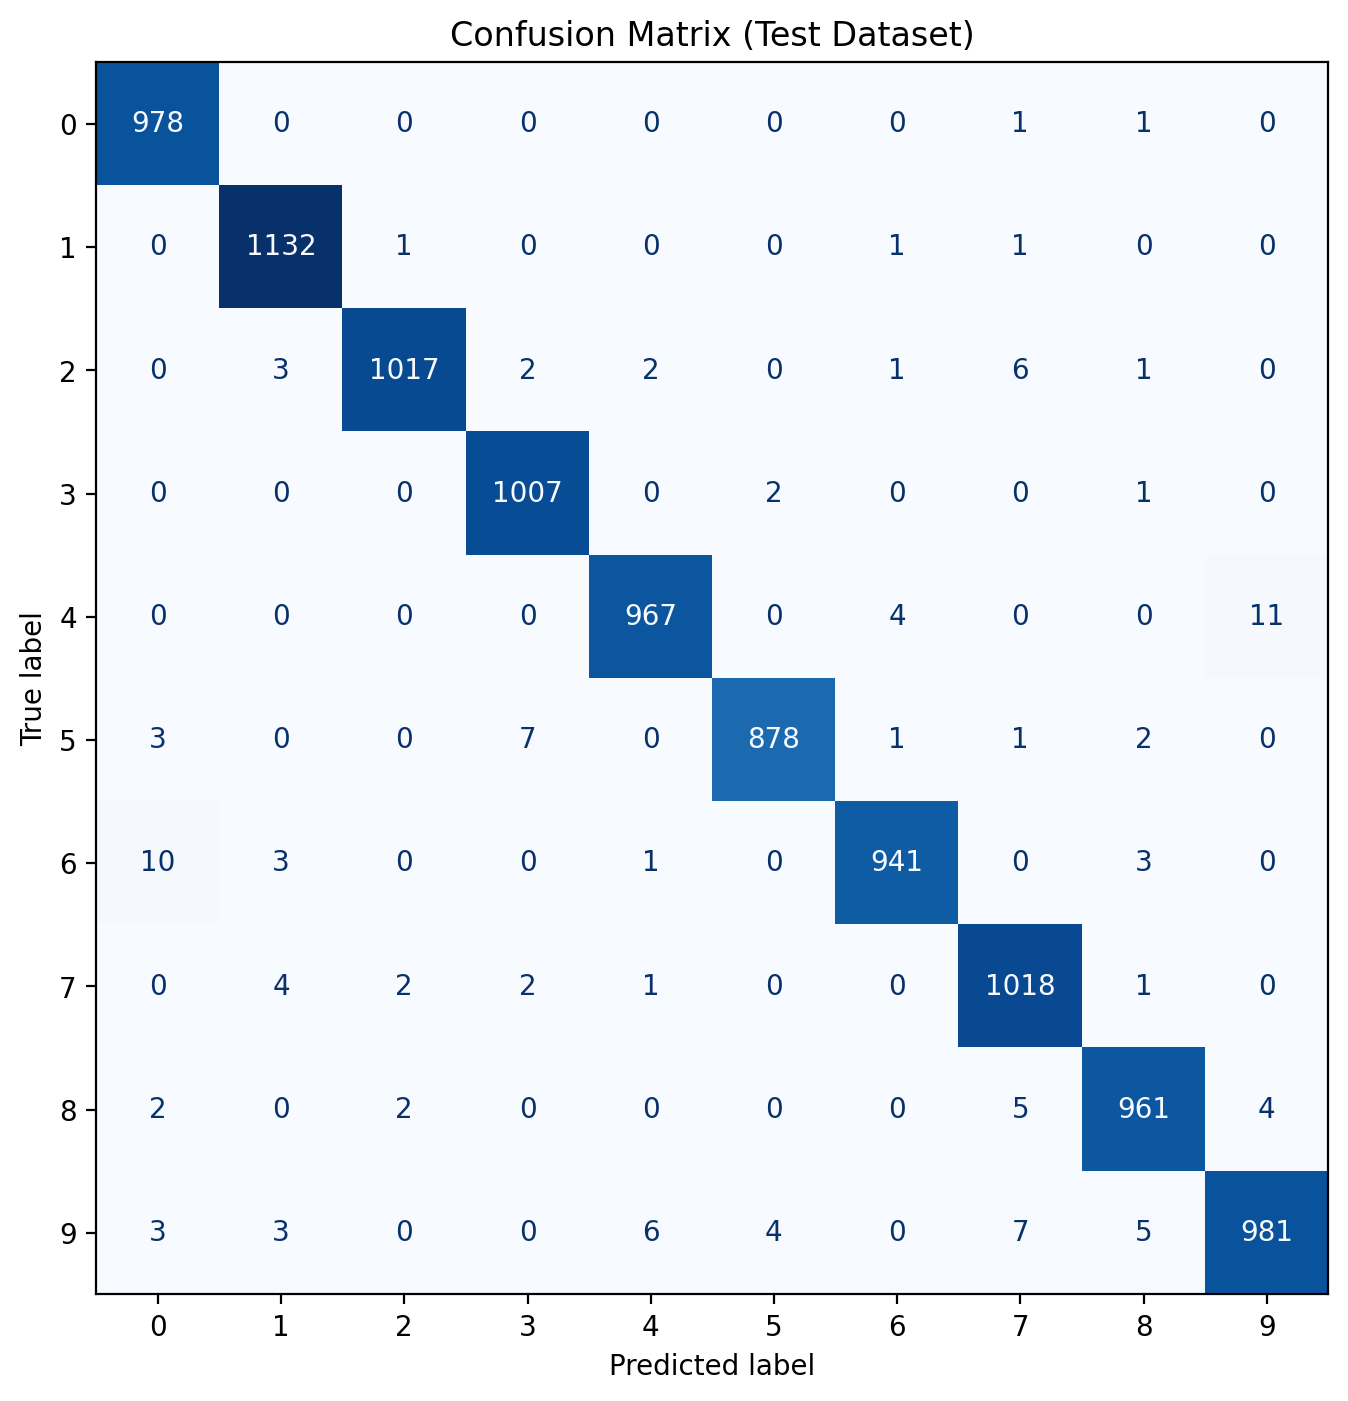

In [36]:
best_config = configs[0] # Adam, lr=0.001, bs=32, filters=20

best_model = create_model(conv2_filters=best_config["filters"], dropout_rate=best_config["dropout"]).to(device)
best_optimizer = optim.Adam(best_model.parameters(), lr=best_config["lr"])
train_loader_best = DataLoader(train_dataset, batch_size=best_config["batch_size"], shuffle=True, num_workers=1)

for epoch in range(5):
    best_model.train()
    for x_train, y_train in train_loader_best:
        x_train, y_train = x_train.to(device), y_train.to(device)
        best_optimizer.zero_grad()
        loss = F.cross_entropy(best_model(x_train), y_train)
        loss.backward()
        best_optimizer.step()

best_model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for x_test, y_test in test_dataloader:
        x_test = x_test.to(device)
        y_pred = best_model(x_test)
        preds = torch.argmax(y_pred, dim=-1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y_test.numpy())

print(classification_report(all_labels, all_preds, digits=4))

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(cmap=plt.cm.Blues, ax=ax, colorbar=False)
plt.title("Confusion Matrix (Test Dataset)")
plt.show()